In [211]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches as ptc
from matplotlib import cm, colors
from tqdm.notebook import tqdm

from defs import *
import stmpy

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [212]:
home_dir = '../../../'
processed_dir = home_dir + 'data/kagome-02.26.2022-center/preprocessed/preprocessed_band/'
out_dir = home_dir + 'output/paper_upload/'

In [213]:
# Define shared parameters

x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4

lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])


L = 0.01 * np.sqrt(3) / 2  # nearest neighbor distance in real space
G = np.array([0, 0])
K = np.array([2 * np.pi / (3 * L), 0])
M = np.array([3 / 2 * np.pi / 3 / L, np.pi / np.sqrt(3) / 2 / L])
BZ_points = rotate_points(K, np.linspace(0, 2 * np.pi, 7, endpoint=True))

kxmax = K[0]
kymax = M[1]*2
kxs = np.linspace(-2*kxmax, 2*kxmax, 150)
kys = np.linspace(-2*kymax, 2*kymax, 150)


In [214]:
freq = 12000.0

with open(processed_dir + f"_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f)

'''
Elements of real_data are assumed to look like:
    0: X in mm
    1: Y in mm
    2: Amplitude
    3: Phase in degrees
'''

sublat_data = [[], [], []]

# Sort the real data into the 3 sublattices
for point in real_data:
    sub_lat = return_sublat_triangle(np.array([0,0]), np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)
    point[0] *= x_unit/1000
    point[1] *= y_unit/1000

    if sub_lat == -1:
        print('Error: point not in any unit cell', point[0], point[1])
    else:
        sublat_data[sub_lat].append(point)



# No symmetrization

  0%|          | 0/150 [00:00<?, ?it/s]

0.488658183025844


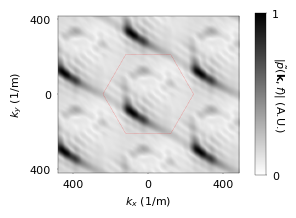

In [215]:
reciprocal_data = np.zeros((3, len(kxs), len(kys)))
    
    
for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):
        for sub_lat_idx in range(len(sub_lat_vecs)):
            reciprocal_data[sub_lat_idx, yi, xi] = fourier_symmetrized_amplitude(sublat_data[sub_lat_idx], np.array([kxs[xi]]), np.array([kys[yi]]))

reciprocal_data = np.average(reciprocal_data, axis=0)

fig, ax, cb = plot_2d_fourier_transform(
    reciprocal_data=reciprocal_data,
    scale=np.max(reciprocal_data),
    cmap=cm.binary,
    vmax=1,
    vmin=0,
    kxs=kxs,
    kys=kys,
    BZ_points=BZ_points,
    out_dir=out_dir,
    freq=freq,
)

print(np.max(reciprocal_data))

# With symmetrization

  0%|          | 0/150 [00:00<?, ?it/s]

0.1557496712475497


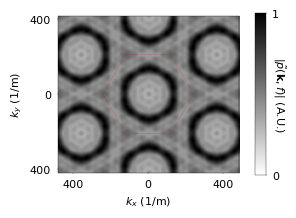

In [216]:
rot_angles = np.linspace(0, 360, 6, endpoint=False) * np.pi / 180

reciprocal_data = np.zeros((len(sub_lat_vecs), len(kxs), len(kys)))

for yi in tqdm(range(len(kys))):
    for xi in range(len(kxs)):
        kx_ops, ky_ops = symmetry_k_points(kxs[xi], kys[yi], rot_angles)

        for sub_lat_idx in range(len(sub_lat_vecs)):
            reciprocal_data[sub_lat_idx, yi, xi] = fourier_symmetrized_amplitude(sublat_data[sub_lat_idx], kx_ops, ky_ops)


reciprocal_data = np.average(reciprocal_data, axis=0)
fig, ax, cb = plot_2d_fourier_transform(
    reciprocal_data=reciprocal_data,
    scale=np.max(reciprocal_data),
    cmap=cm.binary,
    kxs=kxs,
    kys=kys,
    vmin=0,
    vmax=1,
    BZ_points=BZ_points,
    out_dir=out_dir,
    freq=freq,
    save=True,
    save_fn='2D_DFT_symmetrized'
)

print(np.max(reciprocal_data))

# Plot the correponding real space modes

In [217]:
preamp_gain = 4.731513 #13.5 dB at minimum gain
mic_gain = 0.02 #0.02V/Pa 

radius = 3.5

(<Figure size 750x750 with 2 Axes>, <Axes: >)

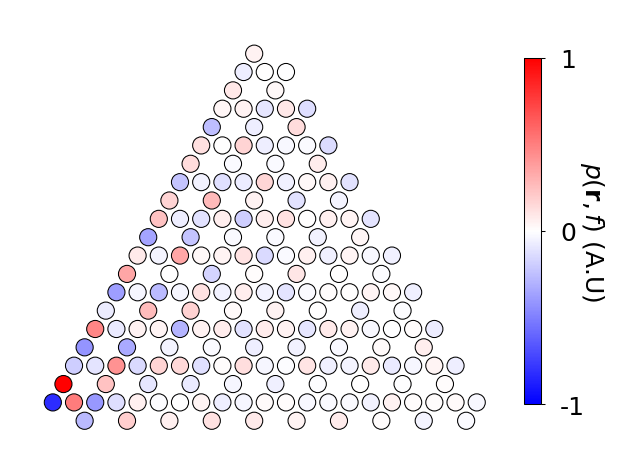

In [222]:
freq = 12000.0

with open(processed_dir + f"_{freq}_0.pkl",'rb') as f:
    real_data = pickle.load(f) 
    
amp = real_data[:, 2] /preamp_gain/mic_gain
max_idx = np.argmax(amp)
phase = real_data[:, 3] - real_data[max_idx, 3]  # phase relative to the max amplitude
x = real_data[:, 0]
y = real_data[:, 1]
value = amp * np.cos(phase/180 * np.pi)

x_coords = x * x_unit
y_coords = y * y_unit
real_space_plot(x_coords=x_coords, y_coords=y_coords, value=value/np.max(amp), radius=radius, 
                max_amp=1,
                cbar_ticks=[-1, 0, 1],
                cbar_label=r'$p(\mathbf{r}, f)$ (A.U)',
                cbar_shrink=0.6,
                xlim=(-5, 185), ylim=(-5, 160),
                out_path=out_dir+f'2D_real_space_{freq}Hz.pdf')